<a href="https://colab.research.google.com/github/MehulShukla-git/Movie_Recommendation_System/blob/main/ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ANN MODEL**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/movies_metadata.csv',
    sep=',',
    engine='python',
    quoting=3,
    on_bad_lines='skip'
)

print(df.shape)
print(df.columns)
df.head()

(33390, 24)
Index(['"adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count"'],
      dtype='object')


"adult  \
"False ""{'id': 10194   'name': 'Toy Story Collection'            'poster_path': '/7G9915LfUQ2lVfwMEEhDsn3kT4B.jpg' 'backdrop_path': '/9FBwqcd9IRruEDUrTdcaafOMKUq.... 30000000   ""[{'id': 16      'name': 'Animation'}  {'id': 35              'name': 'Comedy'}     {'id': 10751  'name': 'Family'}]"" http://toystory.disney.com/toy-story 862                                                                                         tt0114709   
       ""{'id': 119050  'name': 'Grumpy Old Men Collection'       'poster_path': '/nLvUdqgPgm3F85NMCii9gVFUcet.jpg' 'backdrop_path': '/hypTnLot2z8wpFS7qwsQHW1uV8u.... 0          ""[{'id': 10749   'name': 'Romance'}    {'id': 35              'name': 'Comedy'}]"" NaN           15602                 tt0113228                            en                                                                                   Grumpier Old Men   
       NaN             16000000                                  ""[{'id': 35                                       'name': 'Comedy'}                                   {'id': 18  'name': 'Drama'} {'id': 10749          'name': 'Romance'}]"" NaN                   31357         tt0114885             en                                   Waiting to Exhale                                                                        ""Cheated on   
       ""{'id': 96871   'name': 'Father of the Bride Collection'  'poster_path': '/nts4iOmNnq7GNicycMJ9pSAn204.jpg' 'backdrop_path': '/7qwE57OVZmMJChBpLEbJEmzUydk.... 0          ""[{'id': 35      'name': 'Comedy'}]"" NaN                    11862                 tt0113041     en                    Father of the Bride Part II          ""Just when George Banks has recovered from his...   he receives the news that she's pregnant ... ...   
       NaN             62000000                                  ""[{'id': 35                                       'name': 'Comedy'}                                   {'id': 18  'name': 'Drama'} {'id': 10749          'name': 'Romance'}]"" NaN                   9087          tt0112346             en                                   The American President                                       ""Widowed U.S. president Andrew Shepherd   

                                                                                                                                                                                                                                                                                                                                                                                                                               belongs_to_collection  \
"False ""{'id': 10194   'name': 'Toy Story Collection'            'poster_path': '/7G9915LfUQ2lVfwMEEhDsn3kT4B.jpg' 'backdrop_path': '/9FBwqcd9IRruEDUrTdcaafOMKUq.... 30000000   ""[{'id': 16      'name': 'Animation'}  {'id': 35              'name': 'Comedy'}     {'id': 10751  'name': 'Family'}]"" http://toystory.disney.com/toy-story 862                                                                                                en   
       ""{'id': 119050  'name': 'Grumpy Old Men Collection'       'poster_path': '/nLvUdqgPgm3F85NMCii9gVFUcet.jpg' 'backdrop_path': '/hypTnLot2z8wpFS7qwsQHW1uV8u.... 0          ""[{'id': 10749   'name': 'Romance'}    {'id': 35              'name': 'Comedy'}]"" NaN           15602                 tt0113228                            en                                                  ""A family wedding reignites the ancient feud ...   
       NaN             16000000                                  ""[{'id': 35                                       'name': 'Comedy'}                                   {'id': 18  'name': 'Drama'} {'id': 10749          'name': 'Romance'}]"" NaN                   31357         tt0114885             en                                   Waiting to Exhale                                                           mistreated and stepped on   
       ""{'id': 96871   'name

In [4]:
df = df.drop_duplicates().reset_index(drop=True)

df = df[['title', 'overview', 'genres','tagline','vote_average','popularity']]

df = df.dropna(subset=['title'])

df['overview'] = df['overview'].fillna('')
df['tagline'] = df['tagline'].fillna('')

In [5]:
import ast

def extract_genres(x):
    try:
        return " ".join([i['name'] for i in ast.literal_eval(x)])
    except:
        return ""

df['genres'] = df['genres'].apply(extract_genres)

In [6]:
df['tags'] = df['overview'] + " " + df['genres'] + " " + df['tagline']

In [7]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()
    words = [w for w in words if w not in stop_words]
    words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(words)

df['tags'] = df['tags'].apply(preprocess_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [8]:
df = df.reset_index(drop=True)
df['title'] = df['title'].str.lower()

indices = pd.Series(df.index, index=df['title']).drop_duplicates()

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=10000, stop_words='english')

tfidf_matrix = tfidf.fit_transform(df['tags'])

In [25]:
from scipy.sparse import hstack

df['vote_average'] = pd.to_numeric(df['vote_average'], errors='coerce').fillna(0)
df['popularity'] = pd.to_numeric(df['popularity'], errors='coerce').fillna(0)

X_num = df[['popularity']].values

X = hstack((tfidf_matrix, X_num)).tocsr()

In [11]:
df['target'] = df['vote_average'].apply(lambda x: 1 if x >= 6 else 0)

y = df['target']

In [12]:
from sklearn.model_selection import train_test_split

X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_80 = X_train_80.toarray()
X_test_20 = X_test_20.toarray()

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

ann_80 = Sequential()
ann_80.add(Dense(128, activation='relu', input_dim=X_train_80.shape[1]))
ann_80.add(Dense(64, activation='relu'))
ann_80.add(Dense(1, activation='sigmoid'))

ann_80.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

ann_80.fit(X_train_80, y_train_80, epochs=5, batch_size=32)

Epoch 1/5
272/272 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.8557 - loss: 5533.9678
Epoch 2/5
272/272 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - accuracy: 0.8862 - loss: 2104.1624
Epoch 3/5
272/272 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step - accuracy: 0.9341 - loss: 11183.3047
Epoch 4/5
272/272 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.9509 - loss: 2559.6489
Epoch 5/5
272/272 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9587 - loss: 1967.8287


In [14]:
from sklearn.metrics import accuracy_score, precision_score, f1_score, roc_curve, roc_auc_score

y_prob_80 = ann_80.predict(X_test_20)
y_pred_80 = (y_prob_80 > 0.5).astype(int)

print("=== ANN (80-20) ===")
print("Accuracy :", accuracy_score(y_test_20, y_pred_80))
print("Precision:", precision_score(y_test_20, y_pred_80))
print("F1 Score :", f1_score(y_test_20, y_pred_80))

auc_80 = roc_auc_score(y_test_20, y_prob_80)
print("ROC-AUC :", auc_80)

68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
=== ANN (80-20) ===
Accuracy : 0.8583908045977011
Precision: 0.43673469387755104
F1 Score : 0.4099616858237548
ROC-AUC : 0.831244555355628


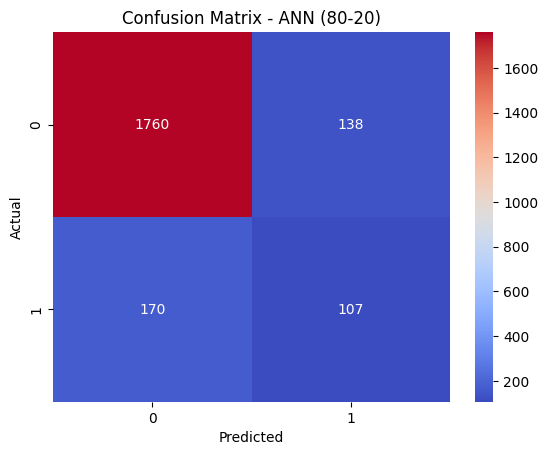

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_flat_80 = y_pred_80.flatten()

cm_80 = confusion_matrix(y_test_20, y_pred_flat_80)

plt.figure()
sns.heatmap(cm_80, annot=True, fmt='d', cmap='coolwarm')
plt.title("Confusion Matrix - ANN (80-20)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

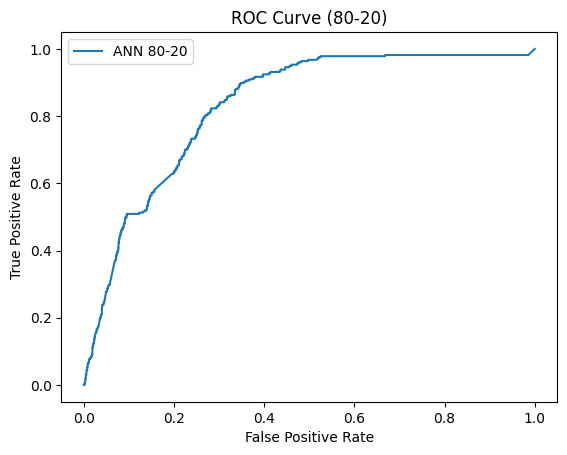

In [16]:
fpr_80, tpr_80, _ = roc_curve(y_test_20, y_prob_80)

plt.figure()
plt.plot(fpr_80, tpr_80, label="ANN 80-20")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (80-20)")
plt.legend()
plt.show()

In [17]:
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_train_70 = X_train_70.toarray()
X_test_30 = X_test_30.toarray()

In [18]:
ann_70 = Sequential()
ann_70.add(Dense(128, activation='relu', input_dim=X_train_70.shape[1]))
ann_70.add(Dense(64, activation='relu'))
ann_70.add(Dense(1, activation='sigmoid'))

ann_70.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

ann_70.fit(X_train_70, y_train_70, epochs=5, batch_size=32)

Epoch 1/5
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8590 - loss: 2798.6680
Epoch 2/5
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.8743 - loss: 3297.2751
Epoch 3/5
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9457 - loss: 1070.1348
Epoch 4/5
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9464 - loss: 3620.7871
Epoch 5/5
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9608 - loss: 2308.5918


In [19]:
y_prob_70 = ann_70.predict(X_test_30)
y_pred_70 = (y_prob_70 > 0.5).astype(int)

print("=== ANN (70-30) ===")
print("Accuracy :", accuracy_score(y_test_30, y_pred_70))
print("Precision:", precision_score(y_test_30, y_pred_70))
print("F1 Score :", f1_score(y_test_30, y_pred_70))

auc_70 = roc_auc_score(y_test_30, y_prob_70)
print("ROC-AUC :", auc_70)

102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
=== ANN (70-30) ===
Accuracy : 0.8648068669527897
Precision: 0.4613003095975232
F1 Score : 0.40324763193504737
ROC-AUC : 0.8331176685226229


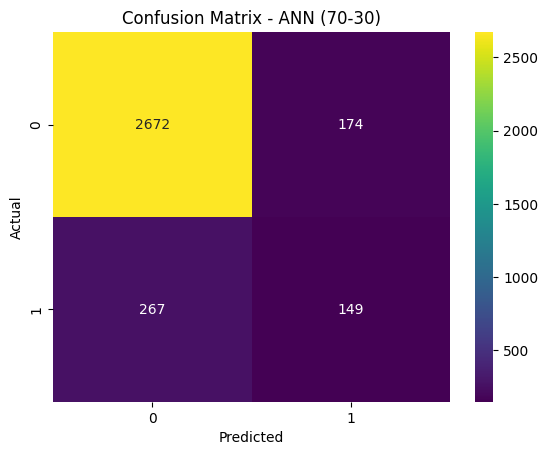

In [20]:
y_pred_flat_70 = y_pred_70.flatten()

cm_70 = confusion_matrix(y_test_30, y_pred_flat_70)

plt.figure()
sns.heatmap(cm_70, annot=True, fmt='d', cmap='viridis')
plt.title("Confusion Matrix - ANN (70-30)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

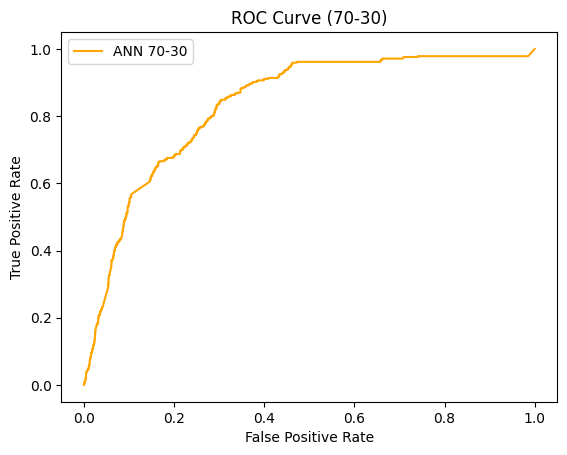

In [21]:
fpr_70, tpr_70, _ = roc_curve(y_test_30, y_prob_70)

plt.figure()
plt.plot(fpr_70, tpr_70, color='orange', label="ANN 70-30")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (70-30)")
plt.legend()
plt.show()

In [22]:
print("\n=== FINAL COMPARISON ===")
print(f"80-20 Accuracy: {accuracy_score(y_test_20, y_pred_80):.4f}")
print(f"70-30 Accuracy: {accuracy_score(y_test_30, y_pred_70):.4f}")


=== FINAL COMPARISON ===
80-20 Accuracy: 0.8584
70-30 Accuracy: 0.8648


In [23]:
from sklearn.metrics.pairwise import cosine_similarity

def recommend_ann(movie_name, top_n=10):
    movie_name = movie_name.lower()

    if movie_name not in indices:
        return "❌ Movie not found"

    idx = indices[movie_name]

    pred = ann_80.predict(X[idx].toarray())[0][0]

    sim_scores = cosine_similarity(X[idx], X).flatten()
    sim_indices = sim_scores.argsort()[-top_n-1:-1][::-1]

    recommended_movies = df['title'].iloc[sim_indices].values

    print(f"\n🎬 Input Movie: {movie_name}")
    print(f"🤖 ANN Score: {pred:.2f}")

    for i, movie in enumerate(recommended_movies, 1):
        print(f"{i}. {movie}")

In [24]:
movie = input("Enter movie name: ").lower()
recommend_ann(movie)

Enter movie name: toy story
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

🎬 Input Movie: toy story
🤖 ANN Score: 0.96
1. toy story 2
2. tri bogatyrya na dalnikh beregakh
3. little longnose
4. slayers return
5. dragon ball: curse of the blood rubies
6. dragon ball z: super android 13
7. dragon ball z: broly - the legendary super saiyan
8. shrek the halls
9. lego dc comics super heroes: batman: be-leaguered
10. a silent voice
